In [1]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

In [2]:
import seaborn as sb

sb.set(rc={'figure.figsize':(11, 4)})
sb.set(font_scale=1.5)

In [3]:
import warnings

warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

## Modelovanje vremenske serije avio-kompanije (broj putnika po mesecu) pomomću AR modela

In [4]:
df = pd.read_csv('airline-passengers.csv')

In [5]:
df.head()

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [6]:
df['Month'] = pd.to_datetime(df['Month'], format='%Y-%m')

df = df.set_index('Month')

df.head()

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


<AxesSubplot:title={'center':'Avio-komanija'}, xlabel='Meseci', ylabel='Broj putnika'>

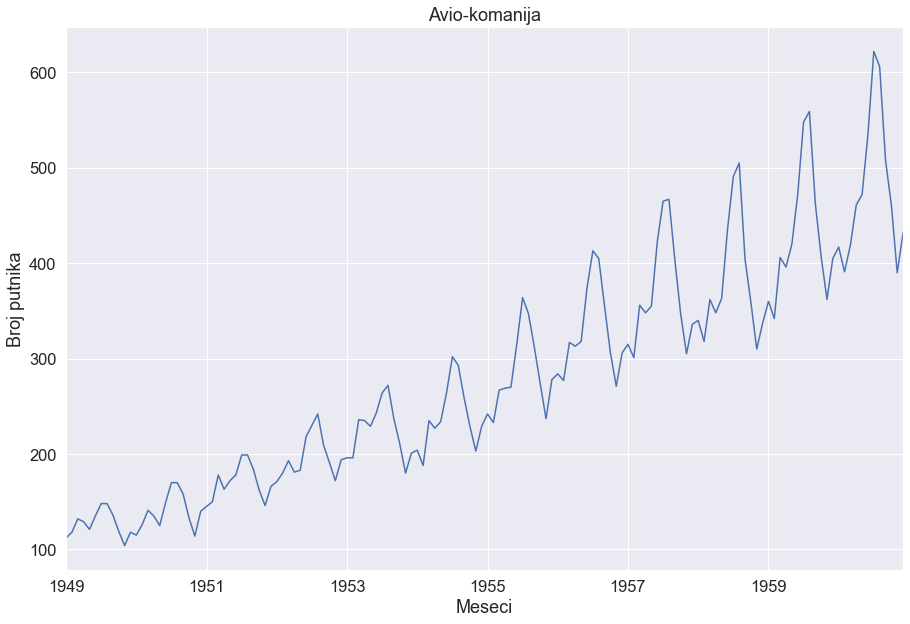

In [7]:
df['Passengers'].plot(figsize=(15,10), title='Avio-komanija', xlabel='Meseci', ylabel='Broj putnika')

#### Sa grafika možemo da vidimo da se magnituda sezonalnosti povećava sa trendom što znači da vremenskoj seriji odgovara multiplikativni model.
#### Ovu informaciju kasnije koristimo u procesu modelovanja.

#### Delimo vremensku seriju na obučavajući i test skup u odnosu 80% prema 20%.

In [8]:
import math

length_train = math.floor(len(df['Passengers'])*0.8)

train = df[:length_train]
test = df[length_train:]

<AxesSubplot:xlabel='Month'>

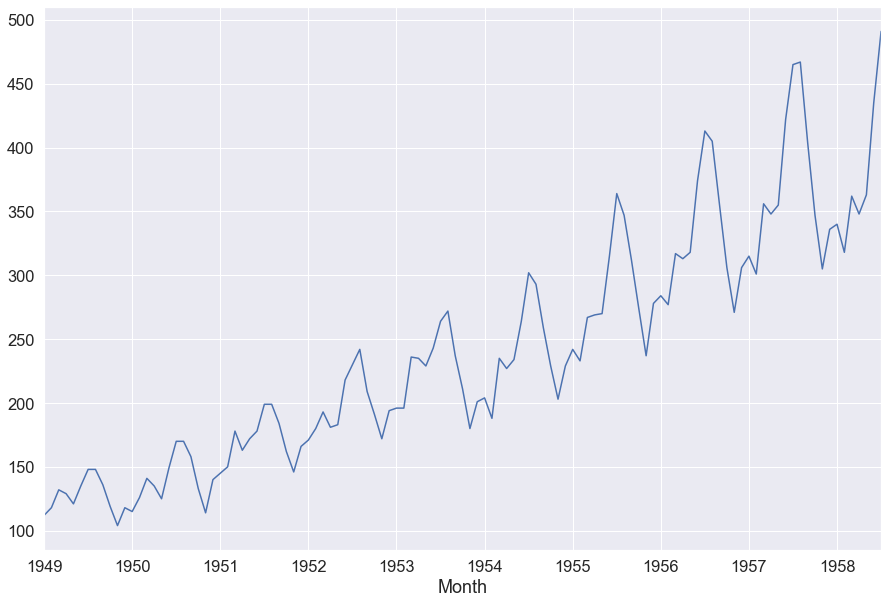

In [9]:
train['Passengers'].plot(figsize=(15,10))

<AxesSubplot:xlabel='Month'>

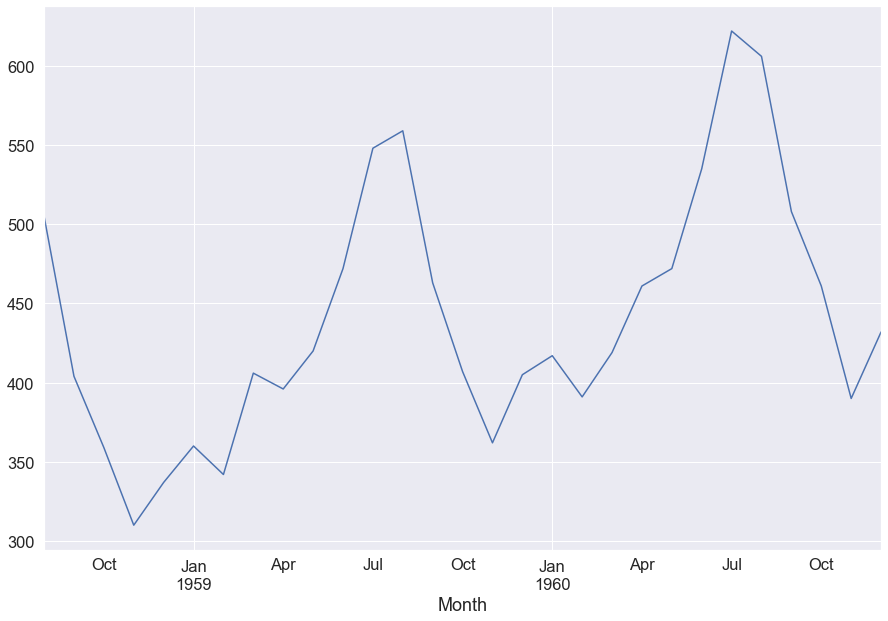

In [10]:
test['Passengers'].plot(figsize=(15,10))

### Formiramo AR model na obučavajućem skupu
#### Prvi korak je analiza autokorelograma radi utvrđivanja da li vremenska serija ima neki šablon ili je pozadinski šum.

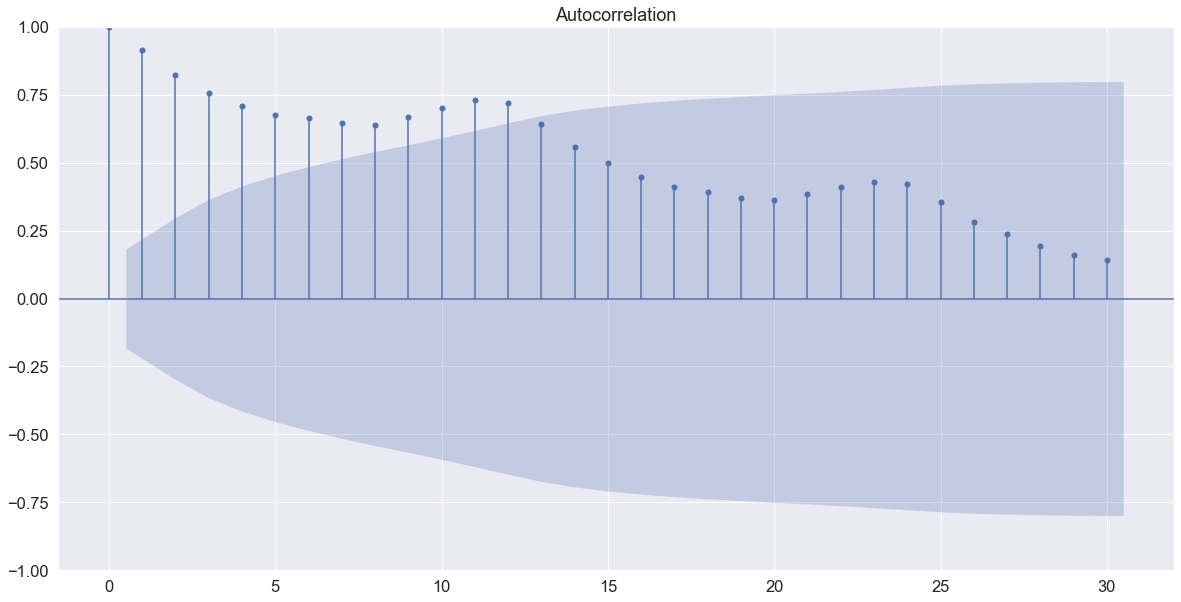

In [11]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

matplotlib.rcParams['figure.figsize']=20,10

plot_acf(train['Passengers'], ax=plt.gca(), lags=30)

plt.show()

#### Pošto imamo vrednosti ACF van osenčenog dela, zaključujemo da vremenska serija nije pozadinski šum i nastavljamo sa modelovanjem.
#### Sledeći korak je provera stacionarnosti jer AR model zahteva stacionarnost.

In [12]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(train['Passengers'])
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
 print('\t%s: %.3f' % (key, value))

ADF Statistic: -0.356889
p-value: 0.917052
Critical Values:
	1%: -3.497
	5%: -2.891
	10%: -2.582


#### Na osnovu p-vrednosti zaključujemo da vremenska serija nije stacionarna.
#### Koristimo STL dekompoziciju da detektujemo trend i sezonalnost kako bi u narednim koracima mogli da dobijemo stacionarnu vremensku seriju.
#### Sa obzirom na to da STL podrazumeva aditivni model, vršimo log10 transformaciju vremenske serije jer na taj način seriju koja sledi multiplikativni model transformišemo u seriju koja sledi aditivni model.

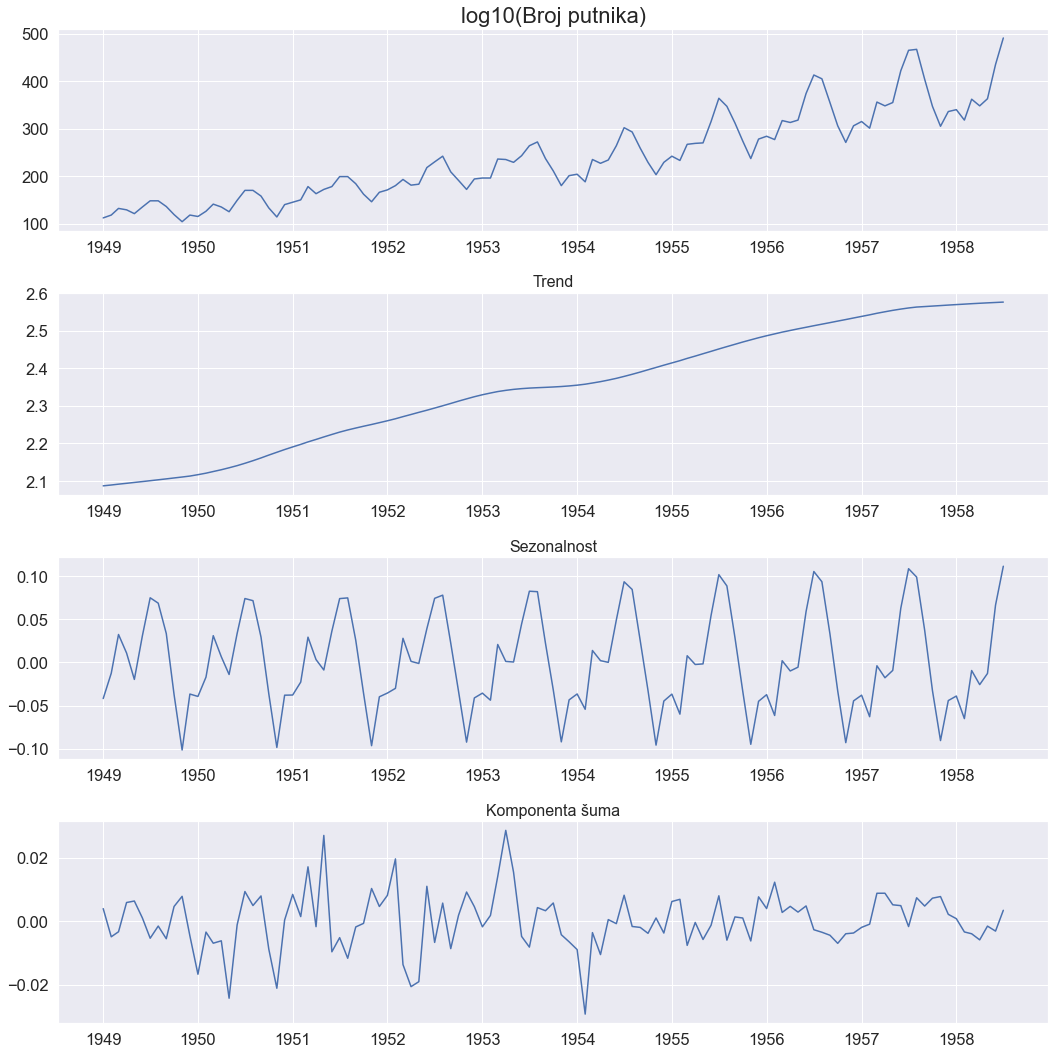

In [13]:
import numpy as np
from statsmodels.tsa.seasonal import STL

train['Log_Passengers'] = np.log10(train['Passengers'])

stl = STL(train['Log_Passengers'])
result_stl = stl.fit()

seasonal, trend, resid = result_stl.seasonal, result_stl.trend, result_stl.resid

plt.figure(figsize=(15,15))

plt.subplot(4,1,1)
plt.plot(train['Passengers'])
plt.title('log10(Broj putnika)', fontsize=22)

plt.subplot(4,1,2)
plt.plot(trend)
plt.title('Trend', fontsize=16)

plt.subplot(4,1,3)
plt.plot(seasonal)
plt.title('Sezonalnost', fontsize=16)

plt.subplot(4,1,4)
plt.plot(resid)
plt.title('Komponenta šuma', fontsize=16)

plt.tight_layout()

#### Možemo da zaključimo da logaritmovana serija ima trend i sezonalnost. U nastavku ćemo ukloniti trend diferenciranjem. Senzonalnost ostavljamo jer ćemo se njome baviti u drugim primerima.
#### Prvo vršimo diferenciranje reda 1 pa proveravamo stacionarnost. Ako je stacionarnost još uvek prisutna onda pokušavamo diferenciranje reda 2.

<AxesSubplot:xlabel='Month'>

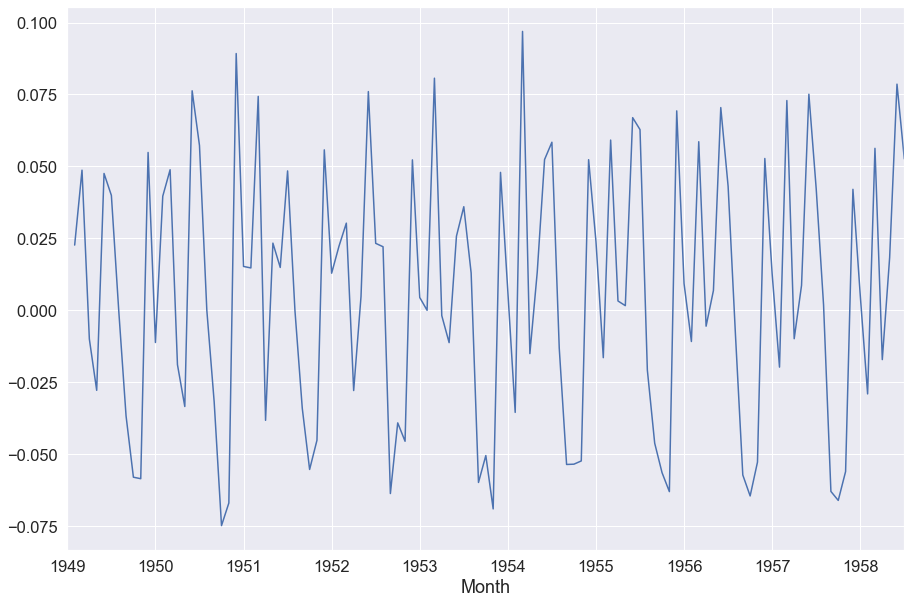

In [14]:
train['Log_Passengers'].diff().plot(figsize=(15,10))

In [15]:
result = adfuller(train['Log_Passengers'].diff().dropna())
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
 print('\t%s: %.3f' % (key, value))

ADF Statistic: -2.635851
p-value: 0.085812
Critical Values:
	1%: -3.497
	5%: -2.891
	10%: -2.582


#### Pošto nismo dobili stacionarnost nakon difernciranja reda 1, radimo diferenciranje reda 2.

In [16]:
result = adfuller(train['Log_Passengers'].diff().diff().dropna())
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
 print('\t%s: %.3f' % (key, value))

ADF Statistic: -7.443433
p-value: 0.000000
Critical Values:
	1%: -3.498
	5%: -2.891
	10%: -2.583


#### Nakon diferenciranja reda 2 dobili smo stacionarnu vremensku seriju.

<AxesSubplot:xlabel='Month'>

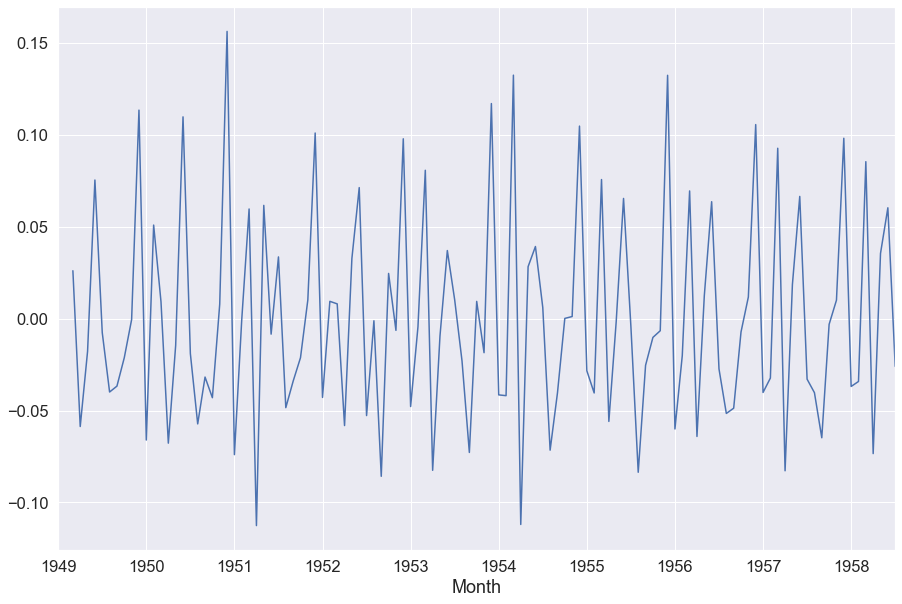

In [17]:
train['Sec_Diff_Log_Passengers'] = train['Log_Passengers'].diff().diff()
train['Sec_Diff_Log_Passengers'].plot(figsize=(15,10))

#### Iscrtavamo sada vrednosti ACF i PACF za stacionarnu vermensku seriju da bi utvrdili red AR modela.

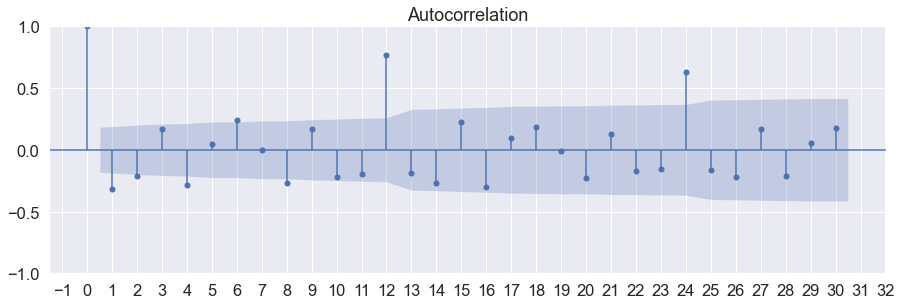

In [18]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

matplotlib.rcParams['figure.figsize']=15,10

ax = plt.subplot(211)

ax.xaxis.set_major_locator(plt.MultipleLocator(1))
ax.xaxis.set_minor_locator(plt.MultipleLocator(1))

plot_acf(train['Sec_Diff_Log_Passengers'].dropna(), ax=plt.gca(), lags=30)

plt.show()

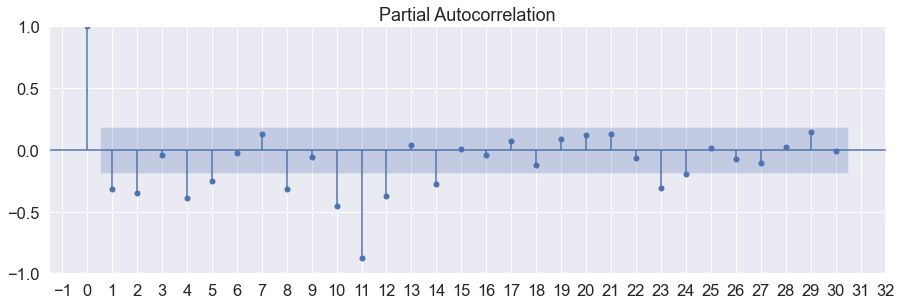

In [20]:
ax = plt.subplot(211)

ax.xaxis.set_major_locator(plt.MultipleLocator(1))
ax.xaxis.set_minor_locator(plt.MultipleLocator(1))

plot_pacf(train['Sec_Diff_Log_Passengers'].dropna(), ax=plt.gca(), lags=30, method='ols')

plt.show()

#### Kao što je pomenuto na predavanjima, za red AR modela koristimo vrednosti PACF. Sa grafika se može videti da imamo značajne vrednosti za k=1,2,4,5,8,10,11,12,... Sa obzirom na to da znamo da u seriji postoji sezonalnost na godinu dana, odabraćemo k=12 za AR model.

#### Obučavamo AR model za k=12.

In [21]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train['Sec_Diff_Log_Passengers'], order=(12,0,0))
results_AR = model.fit()

print(results_AR.summary())

C:\Users\slivk\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\slivk\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\slivk\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                  SARIMAX Results                                  
Dep. Variable:     Sec_Diff_Log_Passengers   No. Observations:                  115
Model:                     ARIMA(12, 0, 0)   Log Likelihood                 264.318
Date:                     Mon, 04 Dec 2023   AIC                           -500.636
Time:                             16:58:17   BIC                           -462.207
Sample:                         01-01-1949   HQIC                          -485.038
                              - 07-01-1958                                         
Covariance Type:                       opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1.589e-05      0.000     -0.071      0.943      -0.000       0.000
ar.L1         -0.9001      0.103     -8.720      0.000      -1.102      -0.698
ar.L2       

C:\Users\slivk\anaconda3\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


#### Prikazujemo grafik predikcija na obučavajućem skupu. Napominjemo da je obučavajući skup stacionarana vremenska serija dobijena primenom log10 trasnformacije i dvostrukog diferenciranja originalne vremenske serije.

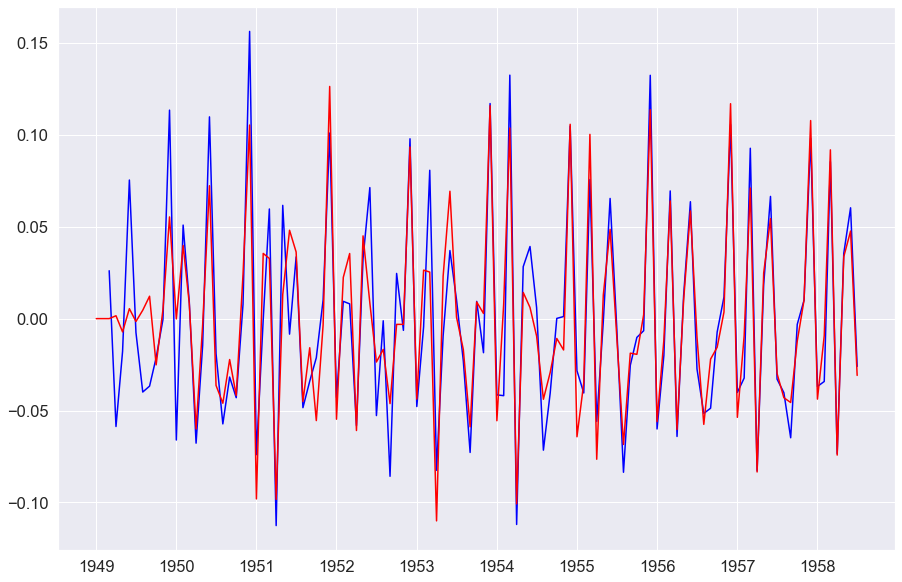

In [23]:
plt.plot(train['Sec_Diff_Log_Passengers'], color='blue')

#start ima smisla tek od 12 jer nam treba 12 prethodnih vrednosti, ali je namerno ostavljeno 0
#da bi se na grafiku videlo da su predikcije za tih prvih 12 meseci loše.
predictions = results_AR.predict(start=train['Sec_Diff_Log_Passengers'].index[0], end=train['Sec_Diff_Log_Passengers'].index[-1])

plt.plot(predictions, color='red')

#### Kako bismo prikazali kako predikcije izgledaju na originalnoj vremenskoji seriji upotrebićemo ARIMA model umesto AR modela. Pri čemu ARIMA model nudi automatsko diferencirenje, ali i inverzne trasformacije koje vraćaju vremensku seriju u originalni oblik.
#### ARIMA model ima 3 ulazna parametra, gde je drugi parametar red diferenciranja, koji postavljamo na 2.

In [24]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train['Log_Passengers'], order=(12,2,0))

results_AR = model.fit()

print(results_AR.summary())

C:\Users\slivk\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\slivk\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\slivk\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:         Log_Passengers   No. Observations:                  115
Model:                ARIMA(12, 2, 0)   Log Likelihood                 271.879
Date:                Mon, 04 Dec 2023   AIC                           -517.758
Time:                        17:02:26   BIC                           -482.302
Sample:                    01-01-1949   HQIC                          -503.371
                         - 07-01-1958                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.2616      0.107    -11.811      0.000      -1.471      -1.052
ar.L2         -1.2772      0.119    -10.698      0.000      -1.511      -1.043
ar.L3         -1.2883      0.127    -10.129      0.0

C:\Users\slivk\anaconda3\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


#### Prikazujemo sada predikcije AR modela na obučavajućem skupu u originalnom obliku (odnosno u log10 od orignialnog oblika jer ARIMA ne radi automastski log10).

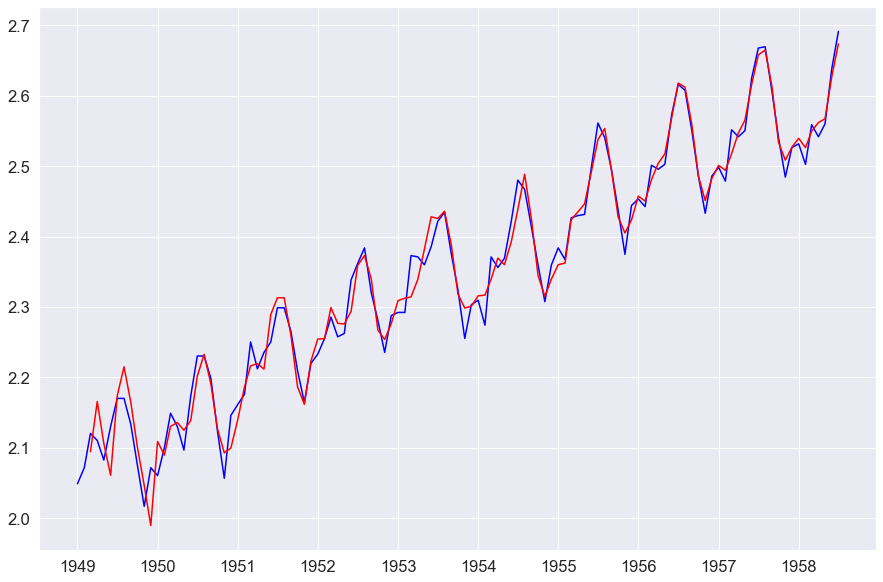

In [25]:
plt.plot(train['Log_Passengers'], color='blue')

predictions = results_AR.predict(start=train['Log_Passengers'].index[2], end=train['Log_Passengers'].index[-1]) #krecemo od index[2] zbog diferenciranja reda 2

plt.plot(predictions, color='red')

#### Primenjujemo sada model na test skup.
#### Prvi korak je log10 transformacija obučavajućeg skupa.

In [26]:
test['Log_Passengers'] = np.log10(test['Passengers'])

In [27]:
test.head()

,Passengers,Log_Passengers
Month,,
1958-08-01,505,2.703291
1958-09-01,404,2.606381
1958-10-01,359,2.555094
1958-11-01,310,2.491362
1958-12-01,337,2.527630


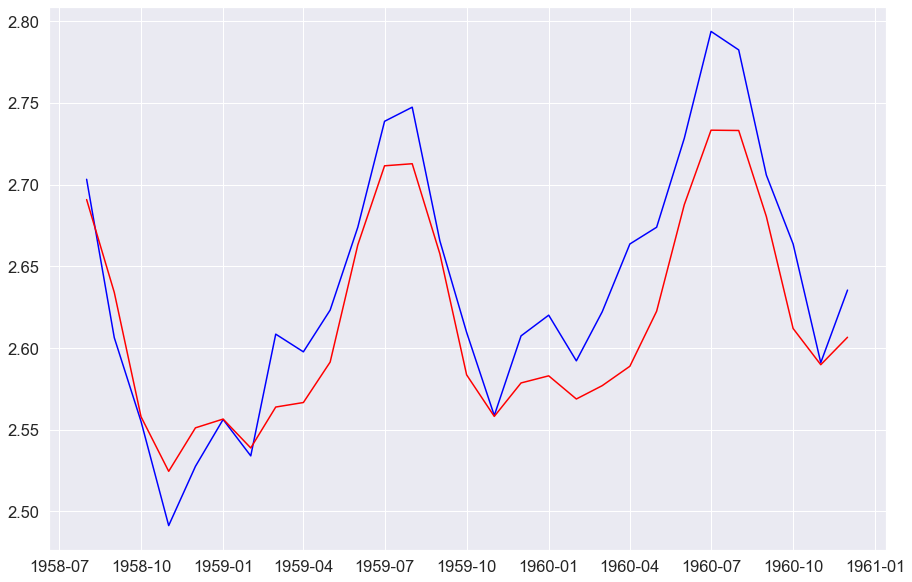

In [28]:
plt.plot(test['Log_Passengers'], color='blue')

predictions = results_AR.predict(start=test['Log_Passengers'].index[0], end=test['Log_Passengers'].index[-1]) #krecemo od index[2] zbog diff reda 2

plt.plot(predictions, color='red')

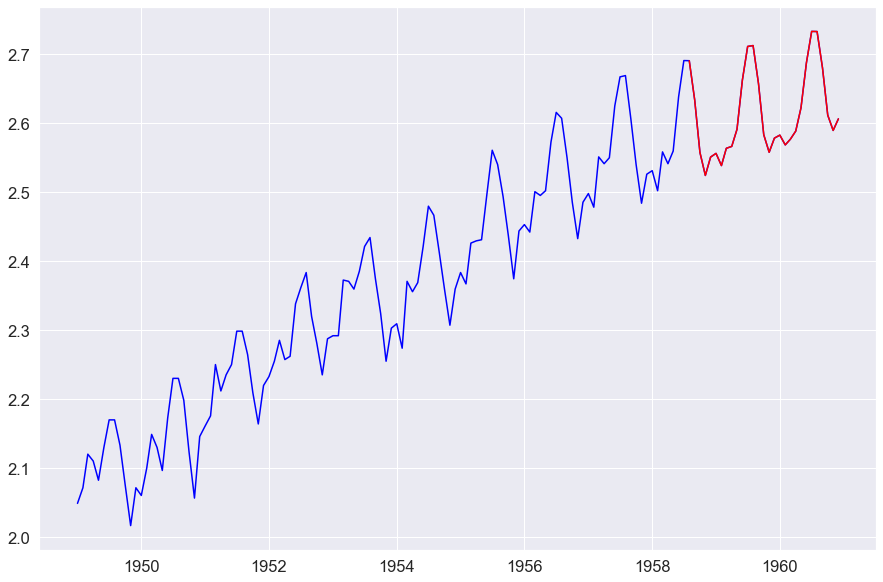

In [29]:
plt.plot(pd.concat((train['Log_Passengers'],predictions),axis=0), color='blue')
plt.plot(predictions, color='red')

#### Prikazujemo vrednosti mera za evaluaciju koje su navedene na predavanjima.

In [30]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

actual_values = test['Log_Passengers']
predicted_values = predictions

mae = mean_absolute_error(actual_values, predicted_values)
print("Mean Absolute Error:", mae)

mse = mean_squared_error(actual_values, predicted_values)
print("Mean Squared Error:", mse)

rmse = np.sqrt(mse)
print("Root Mean Squared Error:", rmse)

mape = np.mean(np.abs((actual_values - predicted_values)/actual_values))*100
print("MAPE:", mape, "%")

def mean_absolute_scaled_error(actual, predicted):
    values = []
    for i in range(1, len(actual)):
        values.append(np.abs(actual[i] - predicted[i]) / np.abs(actual[i] - actual[i - 1]))
    values = np.array(values) / (len(actual) - 1)
    return np.mean(values)

mase = mean_absolute_scaled_error(actual_values, predicted_values)
print("MASE:", mase)

test_err_stat = [mae, mse, rmse, mape, mase]

Mean Absolute Error: 0.02888421462351235
Mean Squared Error: 0.0011826115925012949
Root Mean Squared Error: 0.034389120263555666
MAPE: 1.0866634517014786 %
MASE: 0.04157210420280866


### Evaluacija $k$ koraka unapred (walk forward evaluation)

#### Predikcije na test skupu formiramo tako što predviđanje vršimo samo $k$ perioda unapred, a ne za ceo test skup. 
#### U ovom slučaju birmo $k=1$. Dakle prvo AR model primenjujemo da dobijemo predikcije za avgust 1958. Onda tačnu vrednost (iz test skupa) za avgust 1958 dodajemo u obučavajući skup, obučavamo ponovo model i koristimo ga da dobijemo predkiciju za septembar 1958. Taj postupak nastavljamo za ceo test skup.
#### Ovakva evaluacija modela najviše odgovara realnosti jer se u poslovnom kontekstu retko traže predikcije za veliki broj perioda unapred.

In [31]:
history = [x for x in train['Log_Passengers']]
predictions = list()

for t in range(len(test)):
 model = ARIMA(history, order=(12,2,0))
 model_fit = model.fit(method_kwargs={"warn_convergence": False})
 output = model_fit.forecast()
 yhat = output[0]
 predictions.append(yhat)
 obs = test['Log_Passengers'][t]
 history.append(obs)

rmse = np.sqrt(mean_squared_error(test['Log_Passengers'], predictions))
print('Test RMSE: %.3f' % rmse)

Test RMSE: 0.018


In [32]:
actual_values = test['Log_Passengers']
predicted_values = predictions

mae = mean_absolute_error(actual_values, predicted_values)
print("Mean Absolute Error:", mae)

mse = mean_squared_error(actual_values, predicted_values)
print("Mean Squared Error:", mse)

rmse = np.sqrt(mse)
print("Root Mean Squared Error:", rmse)

mape = np.mean(np.abs((actual_values - predicted_values)/actual_values))*100
print("MAPE:", mape, "%")

mase = mean_absolute_scaled_error(actual_values, predicted_values)
print("MASE:", mase)

test_one_step_err_stat = [mae, mse, rmse, mape, mase]

Mean Absolute Error: 0.01447622752497402
Mean Squared Error: 0.00033235087426200516
Root Mean Squared Error: 0.018230492979127173
MAPE: 0.5499787968765582 %
MASE: 0.014638878375787836


#### Prikazujemo predikcije na test skupu.

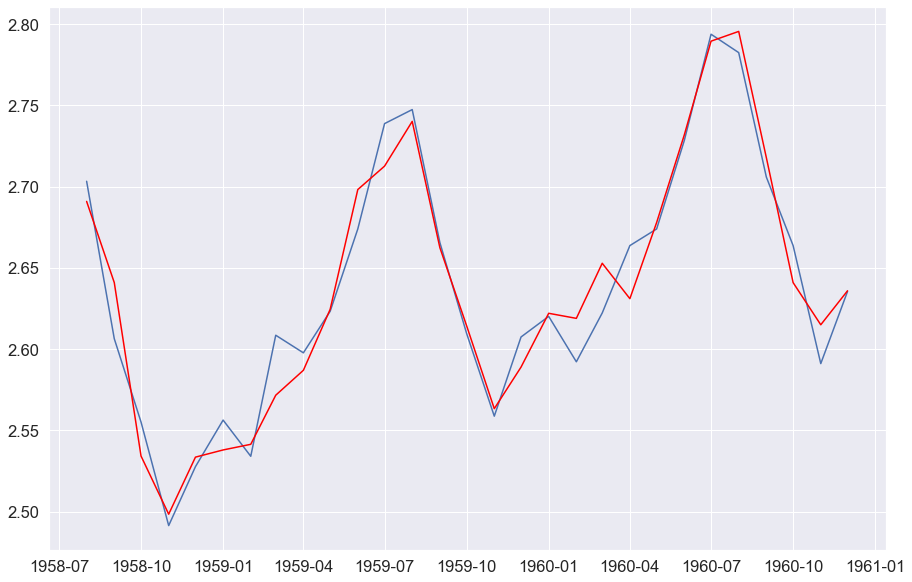

In [33]:
#predictions je lista pa moramo da je dodamo kao novu kolonu u DataFrame da bi bila indeksirana po datumu
test['Log_Passengers_Predictions'] = predictions
plt.plot(test['Log_Passengers'])
plt.plot(test['Log_Passengers_Predictions'], color='red')

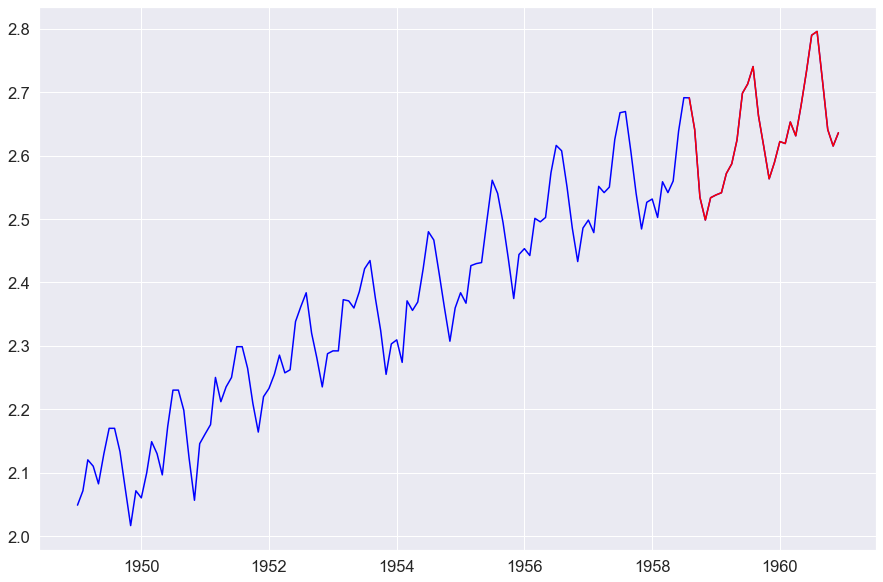

In [35]:
plt.plot(pd.concat((train['Log_Passengers'],test['Log_Passengers_Predictions']),axis=0), color='blue')
plt.plot(test['Log_Passengers_Predictions'], color='red')

### Značaj stacionarnosti

#### U nastavku prikazujemo rezultate AR modela primenjenog na originalnu vremensku seriju bez log10 transformacije i diferenciranja. Razlika u rezultatima između modela ilustruje značaj stacionarnosti za AR model.

C:\Users\slivk\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\slivk\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\slivk\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:             Passengers   No. Observations:                  115
Model:                ARIMA(12, 0, 0)   Log Likelihood                -493.965
Date:                Mon, 04 Dec 2023   AIC                           1015.929
Time:                        17:08:45   BIC                           1054.358
Sample:                    01-01-1949   HQIC                          1031.527
                         - 07-01-1958                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        239.9559    316.618      0.758      0.449    -380.604     860.515
ar.L1          1.1908      0.126      9.434      0.000       0.943       1.438
ar.L2         -0.7226      0.170     -4.255      0.0

C:\Users\slivk\anaconda3\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


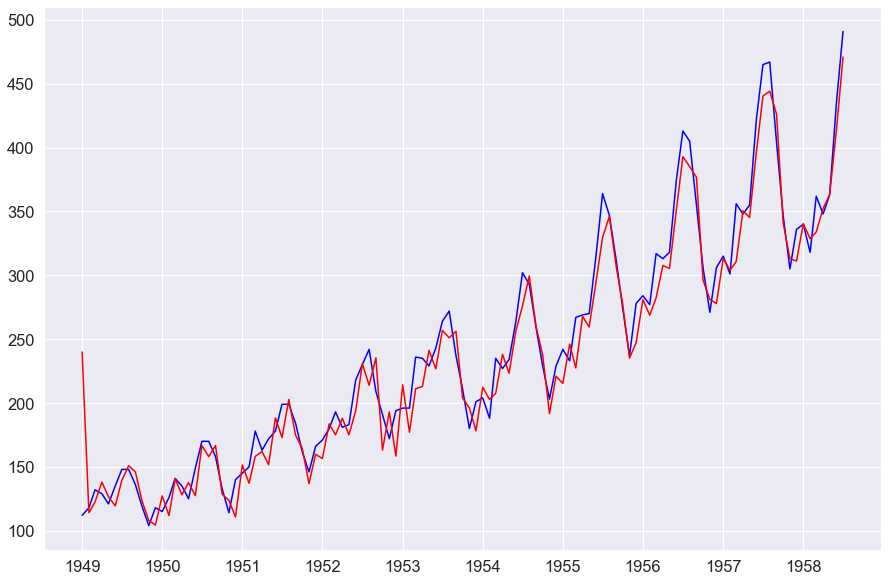

In [36]:
model = ARIMA(train['Passengers'], order=(12,0,0))
results_AR = model.fit()

print(results_AR.summary())

plt.plot(train['Passengers'], color='blue')

predictions = results_AR.predict(start=train['Passengers'].index[0], end=train['Passengers'].index[-1])

plt.plot(predictions, color='red')

#### Primena na test skupu

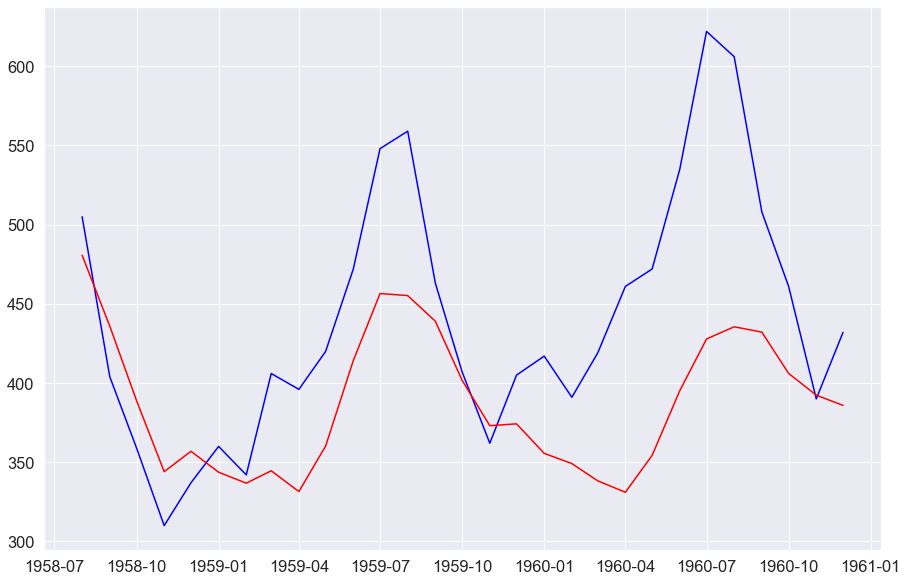

In [38]:
plt.plot(test['Passengers'], color='blue')

predictions = results_AR.predict(start=test['Passengers'].index[0], end=test['Passengers'].index[-1]) #krecemo od index[2] zbog diff reda 2

plt.plot(predictions, color='red')

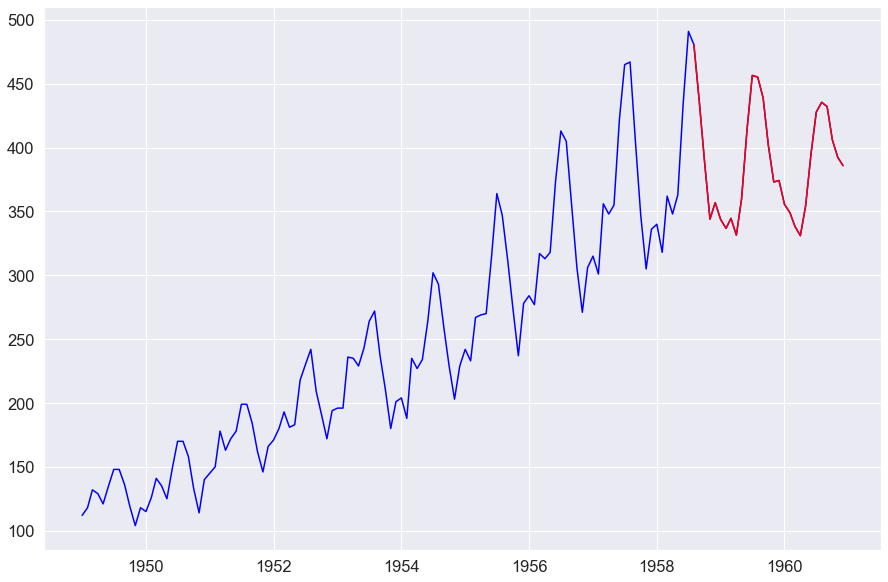

In [39]:
plt.plot(pd.concat((train['Passengers'],predictions),axis=0), color='blue')
plt.plot(predictions, color='red')

In [40]:
actual_values = test['Passengers']
predicted_values = predictions

mae = mean_absolute_error(actual_values, predicted_values)
print("Mean Absolute Error:", mae)

mse = mean_squared_error(actual_values, predicted_values)
print("Mean Squared Error:", mse)

rmse = np.sqrt(mse)
print("Root Mean Squared Error:", rmse)

mape = np.mean(np.abs((actual_values - predicted_values)/actual_values))*100
print("MAPE:", mape, "%")

mase = mean_absolute_scaled_error(actual_values, predicted_values)
print("MASE:", mase)

test_err_non_stat = [mae, mse, rmse, mape, mase]

Mean Absolute Error: 61.61485894188753
Mean Squared Error: 6206.889867708673
Root Mean Squared Error: 78.78381729586776
MAPE: 12.955539702554061 %
MASE: 0.08667242712758016


#### Evaluacija jedan korak unapred

In [41]:
history = [x for x in train['Passengers']]
predictions = list()

for t in range(len(test)):
 model = ARIMA(history, order=(12,0,0))
 model_fit = model.fit(method_kwargs={"warn_convergence": False})
 output = model_fit.forecast()
 yhat = output[0]
 predictions.append(yhat)
 obs = test['Passengers'][t]
 history.append(obs)

In [42]:
test['Predictions'] = predictions

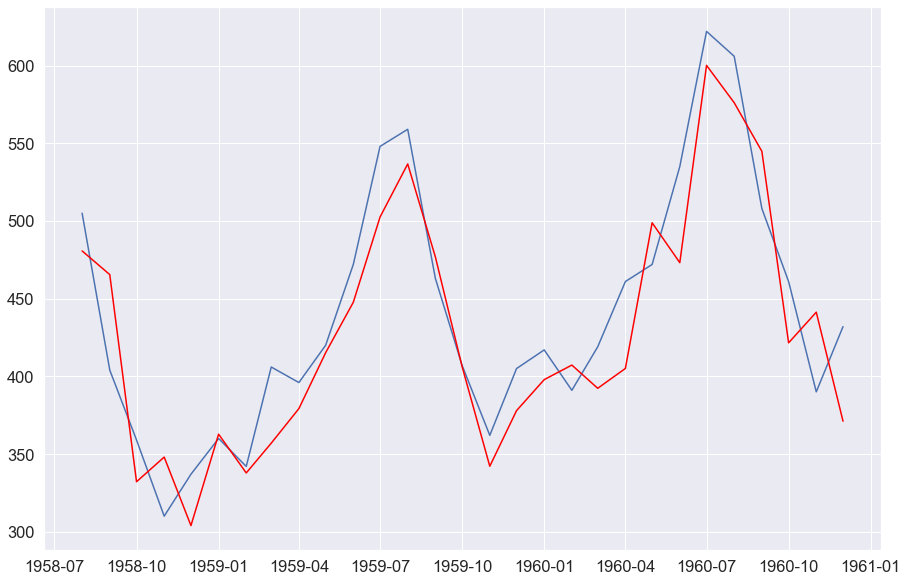

In [43]:
plt.plot(test['Passengers'])
plt.plot(test['Predictions'], color='red')

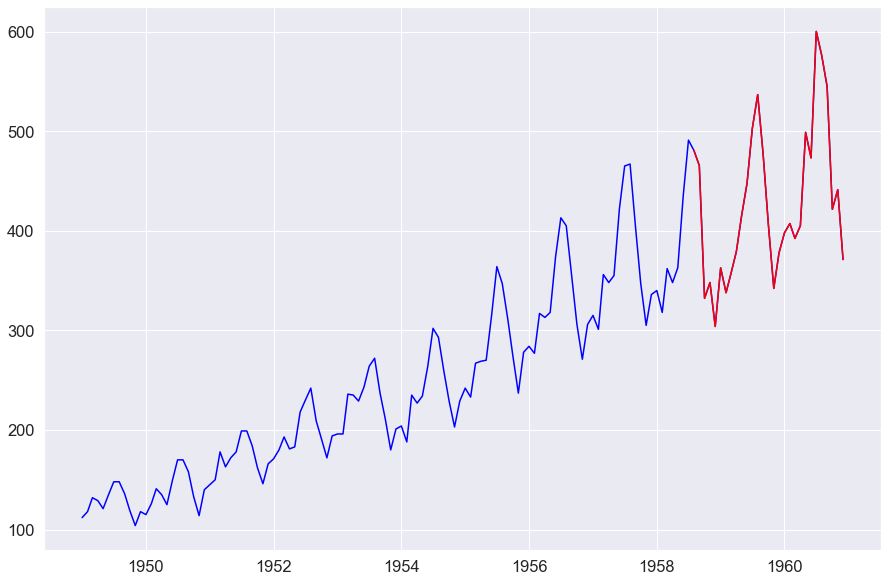

In [44]:
plt.plot(pd.concat((train['Passengers'],test['Predictions']),axis=0), color='blue')
plt.plot(test['Predictions'], color='red')

In [45]:
actual_values = test['Passengers']
predicted_values = predictions

mae = mean_absolute_error(actual_values, predicted_values)
print("Mean Absolute Error:", mae)

mse = mean_squared_error(actual_values, predicted_values)
print("Mean Squared Error:", mse)

rmse = np.sqrt(mse)
print("Root Mean Squared Error:", rmse)

mape = np.mean(np.abs((actual_values - predicted_values)/actual_values))*100
print("MAPE:", mape, "%")

mase = mean_absolute_scaled_error(actual_values, predicted_values)
print("MASE:", mase)

test_one_step_err_non_stat = [mae, mse, rmse, mape, mase]

Mean Absolute Error: 29.71785412976108
Mean Squared Error: 1188.7704776235307
Root Mean Squared Error: 34.47855097917444
MAPE: 6.821381754499992 %
MASE: 0.030558808301703176


In [46]:
print(test_err_stat)
print(test_err_non_stat)

[0.02888421462351235, 0.0011826115925012949, 0.034389120263555666, 1.0866634517014786, 0.04157210420280866]
[61.61485894188753, 6206.889867708673, 78.78381729586776, 12.955539702554061, 0.08667242712758016]


In [49]:
print(test_one_step_err_stat)
print(test_one_step_err_non_stat)

[0.01447622752497402, 0.00033235087426200516, 0.018230492979127173, 0.5499787968765582, 0.014638878375787836]
[29.71785412976108, 1188.7704776235307, 34.47855097917444, 6.821381754499992, 0.030558808301703176]


In [50]:
results = pd.DataFrame([test_err_stat,test_err_non_stat,[0,0,0,100,0]], columns=['MAE', 'MSE', 'RMSE', 'MAPE', 'MASE'])
results['MODEL'] = ['AR(12) stationary', 'AR(12) non stationary', 'MAPE = 100%']

In [51]:
results

,MAE,MSE,RMSE,MAPE,MASE,MODEL
0,0.028884,0.001183,0.034389,1.086663,0.041572,AR(12) stationary
1,61.614859,6206.889868,78.783817,12.955540,0.086672,AR(12) non stationary
2,0.000000,0.000000,0.000000,100.000000,0.000000,MAPE = 100%
